In [1]:

import pandas as pd
import os
import numpy as np
import sys
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
home_dir = "/well/ansari/users/osr869/host/"
sys.path.append(f"{home_dir}software/lcwgsus/")
import lcwgsus
from lcwgsus.variables import *

In [ ]:
#sample that failed calculate_uncov becuase the bedgraph is too big
uncov = [i.split('_')[0] for i in os.listdir("../results/coverage/uncov/samples/")]
samples = pd.read_csv('../data/sample_tsvs/samples_lc.tsv', header=None)[0]
set(samples) - set(uncov)

In [21]:

def merge_metrics_outer(cov_all, uncov_all, dup_all, sex_all, hla_all, save=False, outdir=None, save_name=None):
    coverage = pd.read_csv(cov_all, sep = '\t', header = None)
    coverage.columns = ['sample', 'coverage']

    hla_coverage = pd.read_csv(hla_all, sep = '\t', header = None)
    hla_coverage.columns = ['sample', 'hla_coverage']

    uncoverage = pd.read_csv(uncov_all, sep = '\t', header = None)
    uncoverage.columns = ['sample', 'uncoverage']
    
    dup_rate = pd.read_csv(dup_all, sep = '\t', header = None)
    dup_rate.columns = ['sample', 'dup_rate']

    sex = pd.read_csv(sex_all, sep = '\t', header = None)
    sex.columns = ['sample', 'chrX', 'chrY']
    
    metrics = pd.merge(coverage, hla_coverage, on = 'sample', how='outer')
    metrics = pd.merge(metrics, dup_rate, on = 'sample', how='outer')
    metrics = pd.merge(metrics, uncoverage, on = 'sample', how='outer')
    metrics['skew'] = 0
    
    def calculate_skew(r):
        uncov = r['uncoverage']
        cov = r['coverage']
        r['skew'] = uncov/poisson.pmf(0, cov)
        return r
    
    metrics = metrics.apply(calculate_skew, axis = 1)
    metrics = pd.merge(metrics, sex, on = 'sample', how='outer')
    
    #save_tsv(metrics, save, outdir, save_name)
    return metrics

In [ ]:
dup_rate_all = "../results/dup_rate/dup_rate_all.tsv"
cov_all = "../results/coverage/depth_all.tsv"
uncov_all = "../results/coverage/uncov_all.tsv"
sex_all = "../results/coverage/sex_all.tsv"
hla_all = "../results/coverage/hla_depth_all.tsv"

metrics = merge_metrics_outer(cov_all, uncov_all, dup_rate_all,
        sex_all, hla_all, True, '../results/', 'metrics.tsv')

metrics.to_csv('../results/metrics.tsv', sep='\t', index=False)

In [ ]:
#normal
0.035/poisson.pmf(0, 3.9)

1.729085718693556

In [ ]:
#outlier

0.04/poisson.pmf(0, 5.8324)

13.647060836766947

In [8]:
poisson.pmf(0, 5.8324)

0.002931034050367448

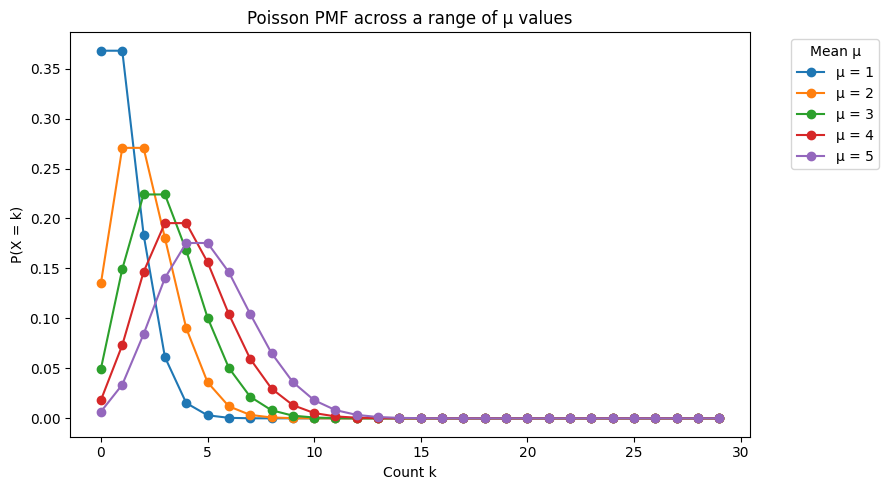

In [ ]:



# Range of Poisson means
mu_values = np.arange(1, 6)   # μ = 1, 2, ..., 10

# Choose x-axis range large enough for the largest μ
k = np.arange(0, 30)

plt.figure(figsize=(9, 5))

for mu in mu_values:
    pmf = poisson.pmf(k, mu)
    plt.plot(k, pmf, marker="o", label=f"μ = {mu}")

plt.xlabel("Count k")
plt.ylabel("P(X = k)")
plt.title("Poisson PMF across a range of μ values")
plt.legend(title="Mean μ", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [2]:
#CHECK SEX DISCORDANCE
#extract all picard DuplicationMetrics
mismatched_samples = ["22DX02-0591-201", "22DX02-0605-201", "22DX02-0615-201", "22DX02-0665-201", 
"22DX03-0122-201", "22DX03-0869-201", "22DX03-0870-202", "22DX03-0885-201", 
"22DX03-0888-201", "22DX03-0892-202", "22DX03-1084-201", "22DX07-0708-201", 
"22DX07-0722-201", "22DX07-0723-203"]
samples = pd.read_csv('../data/sample_tsvs/samples_lc.tsv', header=None)[0]
dup_metrics = pd.read_csv("../results/duplication_metrics_combined.tsv", sep='\t')
dup_metrics["Cohort"] = dup_metrics.SAMPLE.str[:4]
dup22 = dup_metrics[(dup_metrics.Cohort == "22DX") & (dup_metrics.PERCENT_DUPLICATION < 0.15)]
dup22['Mismatch'] = [ s in mismatched_samples for s in dup22.SAMPLE]
dup22 = dup22.sort_values("Mismatch")

/tmp/ipykernel_2036298/2696776708.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dup22['Mismatch'] = [ s in mismatched_samples for s in dup22.SAMPLE]


<Axes: xlabel='UNMAPPED_READS', ylabel='PERCENT_DUPLICATION'>

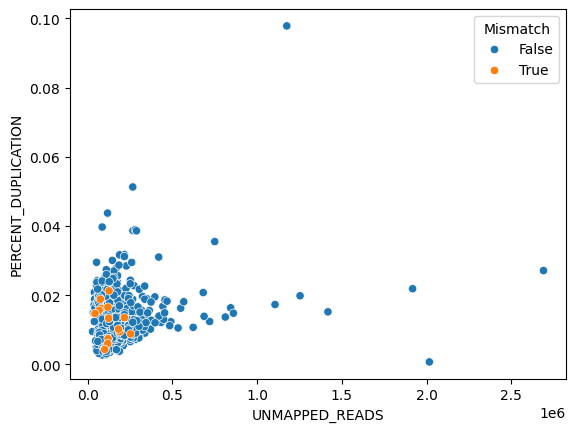

In [22]:

sns.scatterplot(data=dup22, x='UNMAPPED_READS', y='PERCENT_DUPLICATION',
            hue='Mismatch')

<Axes: xlabel='UNPAIRED_READS_EXAMINED', ylabel='READ_PAIRS_EXAMINED'>

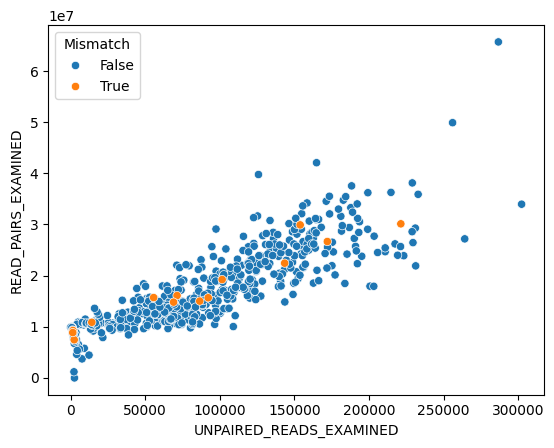

In [23]:
sns.scatterplot(data=dup22, x='UNPAIRED_READS_EXAMINED', y='READ_PAIRS_EXAMINED',
            hue='Mismatch')

<Axes: xlabel='SECONDARY_OR_SUPPLEMENTARY_RDS', ylabel='UNMAPPED_READS'>

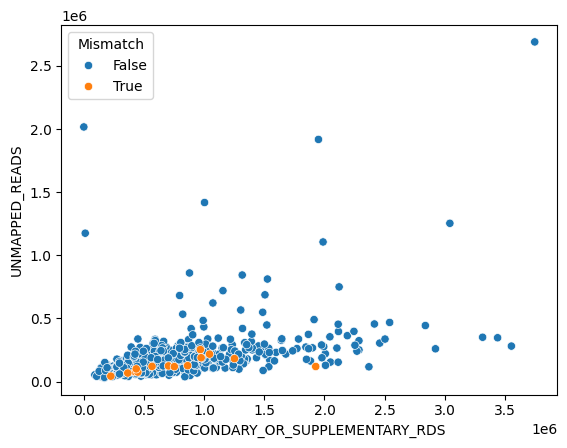

In [29]:

sns.scatterplot(data=dup22, x='SECONDARY_OR_SUPPLEMENTARY_RDS', y='UNMAPPED_READS',
            hue='Mismatch')

In [3]:
#result from PLINK based on nonPAR
dfcheck = pd.read_csv("../results/X_check/sexcheck_summary.tsv", sep="\t")
dfcheck['SAMPLE'] = dfcheck.sample_id
dfcheck = dfcheck.merge(dup22, on="SAMPLE", how="left")
dfcheck = dfcheck.sort_values("Mismatch")

dfmeta = pd.read_csv("../../plots/metrics_22dx_sex.txt", sep="\t")
dfmeta["SAMPLE"] = dfmeta['sample']
dfcheck = dfcheck.merge(dfmeta, on="SAMPLE", how="left")

In [5]:
dfcheck.columns

Index(['sample_id', 'FID', 'IID', 'PEDSEX', 'SNPSEX', 'STATUS', 'F',
       'HET_COUNT', 'CALLED_SITES', 'HET_RATE', 'MEAN_DP',
       'ALLELE_BALANCE_MEAN', 'GQ_0_9', 'GQ_10_19', 'GQ_20_29', 'GQ_30_39',
       'GQ_40_PLUS', 'GQ_MISSING', 'SAMPLE', 'LIBRARY',
       'UNPAIRED_READS_EXAMINED', 'READ_PAIRS_EXAMINED',
       'SECONDARY_OR_SUPPLEMENTARY_RDS', 'UNMAPPED_READS',
       'UNPAIRED_READ_DUPLICATES', 'READ_PAIR_DUPLICATES',
       'READ_PAIR_OPTICAL_DUPLICATES', 'PERCENT_DUPLICATION',
       'ESTIMATED_LIBRARY_SIZE', 'Cohort', 'Mismatch', 'sample', 'Sex',
       'coverage', 'hla_coverage', 'dup_rate', 'uncoverage', 'skew', 'chrX',
       'chrY', 'Studycode', 'StudyNo', 'code-match', 'serotype',
       'RNA-PlateID-Position', 'old-vir (copies/mL)', 'Cp-new',
       'new-vir (copies/mL)', 'DNA-PlateID-Position', 'DNA Conc. (ng/uL)',
       '260/280'],
      dtype='object')

<Axes: xlabel='Sex', ylabel='HET_RATE'>

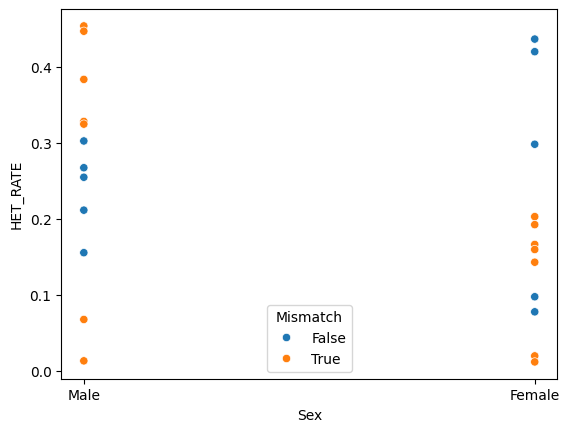

In [ ]:
sns.scatterplot(data=dfcheck, x='Sex', y='HET_RATE',
            hue='sex')

<Axes: xlabel='CALLED_SITES', ylabel='HET_RATE'>

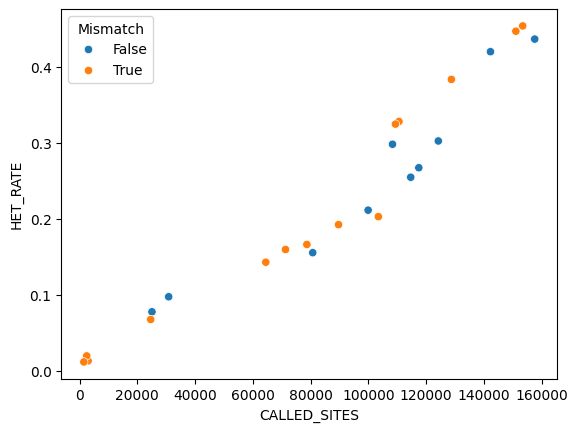

In [69]:
sns.scatterplot(data=dfcheck, x='CALLED_SITES', y='HET_RATE',
            hue='Mismatch')

<Axes: xlabel='MEAN_DP', ylabel='HET_RATE'>

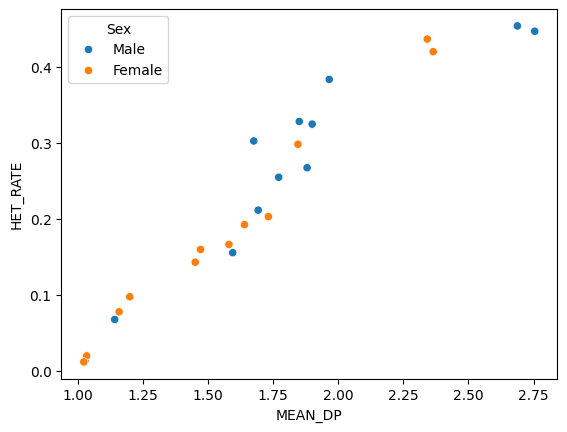

In [61]:
sns.scatterplot(data=dfcheck, x='MEAN_DP', y='HET_RATE',
            hue='Sex')

<Axes: xlabel='HET_COUNT', ylabel='HET_RATE'>

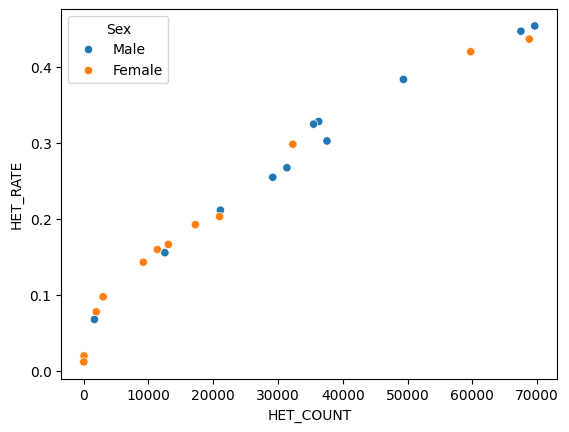

In [62]:
sns.scatterplot(data=dfcheck, x='HET_COUNT', y='HET_RATE',
            hue='Sex')

<Axes: >

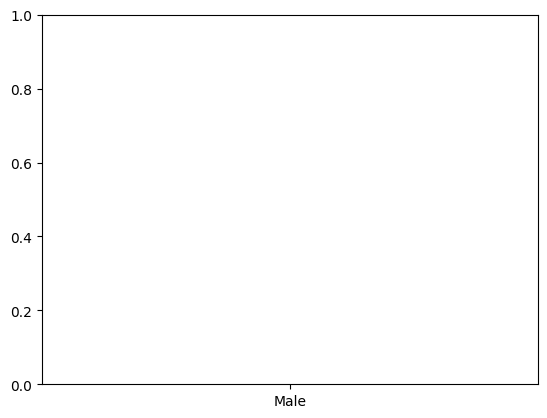

In [65]:
sns.scatterplot(data=dfcheck, x='Sex', y='ALLELE_BALANCE_MEAN',
            hue='Sex')

In [ ]:
dfcheck.columns

Index(['sample_id', 'FID', 'IID', 'PEDSEX', 'SNPSEX', 'STATUS', 'F',
       'HET_COUNT', 'CALLED_SITES', 'HET_RATE', 'MEAN_DP',
       'ALLELE_BALANCE_MEAN', 'GQ_0_9', 'GQ_10_19', 'GQ_20_29', 'GQ_30_39',
       'GQ_40_PLUS', 'GQ_MISSING', 'SAMPLE', 'LIBRARY',
       'UNPAIRED_READS_EXAMINED', 'READ_PAIRS_EXAMINED',
       'SECONDARY_OR_SUPPLEMENTARY_RDS', 'UNMAPPED_READS',
       'UNPAIRED_READ_DUPLICATES', 'READ_PAIR_DUPLICATES',
       'READ_PAIR_OPTICAL_DUPLICATES', 'PERCENT_DUPLICATION',
       'ESTIMATED_LIBRARY_SIZE', 'Cohort', 'Mismatch', 'sample', 'Sex',
       'coverage', 'hla_coverage', 'dup_rate', 'uncoverage', 'skew', 'chrX',
       'chrY', 'Studycode', 'StudyNo', 'code-match', 'serotype',
       'RNA-PlateID-Position', 'old-vir (copies/mL)', 'Cp-new',
       'new-vir (copies/mL)', 'DNA-PlateID-Position', 'DNA Conc. (ng/uL)',
       '260/280'],
      dtype='object')

In [67]:
dfcheck

,sample_id,FID,IID,PEDSEX,SNPSEX,STATUS,F,HET_COUNT,CALLED_SITES,HET_RATE,...,StudyNo,code-match,serotype,RNA-PlateID-Position,old-vir (copies/mL),Cp-new,new-vir (copies/mL),DNA-PlateID-Position,DNA Conc. (ng/uL),260/280
0,22DX02-0002-202,22DX02-0002-202,22DX02-0002-202,0,2,PROBLEM,-1,31372,117502,0.266991,...,2.0,22DX02-0002,DENV1,RNA-25-002-A1,1.101000e+09,22.61,2.513333e+07,DNA-24-001-A1,46.4,1.80
1,22DX03-1048-203,22DX03-1048-203,22DX03-1048-203,0,2,PROBLEM,-1,12531,80766,0.155152,...,1048.0,22DX03-1048,DENV1,RNA-25-006-B6,4.351000e+08,24.01,1.233333e+07,DNA-24-005-G4,277.2,1.90
2,22DX03-1045-201,22DX03-1045-201,22DX03-1045-201,0,2,PROBLEM,-1,1940,25098,0.077297,...,1045.0,22DX03-1045,DENV1,RNA-25-006-A6,5.577000e+08,29.49,2.866667e+05,DNA-24-005-F4,21.4,1.72
3,22DX02-0933-201,22DX02-0933-201,22DX02-0933-201,0,2,PROBLEM,-1,29186,114699,0.254457,...,933.0,22DX02-0933,DENV1,RNA-25-004-H2,4.660000e+08,23.52,6.073333e+06,DNA-24-007-D7,60.0,1.66
4,22DX02-0934-201,22DX02-0934-201,22DX02-0934-201,0,2,PROBLEM,-1,32290,108390,0.297906,...,934.0,22DX02-0934,DENV1,RNA-25-004-A3,3.010000e+07,30.20,5.526667e+04,DNA-24-007-E7,63.9,1.83
5,22DX02-0935-201,22DX02-0935-201,22DX02-0935-201,0,2,PROBLEM,-1,59733,142308,0.419744,...,935.0,22DX02-0935,DENV1,RNA-25-004-B3,1.450000e+07,22.88,9.533333e+06,DNA-24-007-F7,80.2,1.76
6,22DX02-0947-202,22DX02-0947-202,22DX02-0947-202,0,2,PROBLEM,-1,21103,99947,0.211142,...,947.0,22DX02-0947,DENV1,RNA-25-004-B4,1.000000e+07,30.58,4.213333e+04,DNA-24-007-F8,71.8,1.63
7,22DX02-0977-201,22DX02-0977-201,22DX02-0977-201,0,2,PROBLEM,-1,68785,157641,0.436340,...,977.0,22DX02-0977,DENV1,RNA-25-004-A6,5.180000e+06,30.43,4.673333e+04,DNA-24-007-E10,67.4,1.61
8,22DX03-1044-201,22DX03-1044-201,22DX03-1044-201,0,2,PROBLEM,-1,3000,30881,0.097147,...,1044.0,22DX03-1044,DENV1,RNA-25-006-H5,5.893000e+07,28.17,8.200000e+05,DNA-24-005-E4,89.7,1.99
9,22DX03-1041-202,22DX03-1041-202,22DX03-1041-202,0,2,PROBLEM,-1,37551,124255,0.302209,...,1041.0,22DX03-1041,DENV1,RNA-25-006-G5,1.720000e+08,20.91,7.533333e+07,DNA-24-005-D4,140.4,1.87


In [68]:
49354/128774

0.38326059608306023